In [25]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [26]:
loans=pd.read_csv("loan_data.csv")
loans

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0,all_other,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,1
9574,0,all_other,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,1
9575,0,debt_consolidation,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,1
9576,0,home_improvement,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,1


In [27]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [28]:
str(loans)

'      credit.policy             purpose  int.rate  installment  \\\n0                 1  debt_consolidation    0.1189       829.10   \n1                 1         credit_card    0.1071       228.22   \n2                 1  debt_consolidation    0.1357       366.86   \n3                 1  debt_consolidation    0.1008       162.34   \n4                 1         credit_card    0.1426       102.92   \n...             ...                 ...       ...          ...   \n9573              0           all_other    0.1461       344.76   \n9574              0           all_other    0.1253       257.70   \n9575              0  debt_consolidation    0.1071        97.81   \n9576              0    home_improvement    0.1600       351.58   \n9577              0  debt_consolidation    0.1392       853.43   \n\n      log.annual.inc    dti  fico  days.with.cr.line  revol.bal  revol.util  \\\n0          11.350407  19.48   737        5639.958333      28854        52.1   \n1          11.082143  14.29   7

In [29]:
loans.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


In [30]:
loans['not.fully.paid'].value_counts()

not.fully.paid
0    8045
1    1533
Name: count, dtype: int64

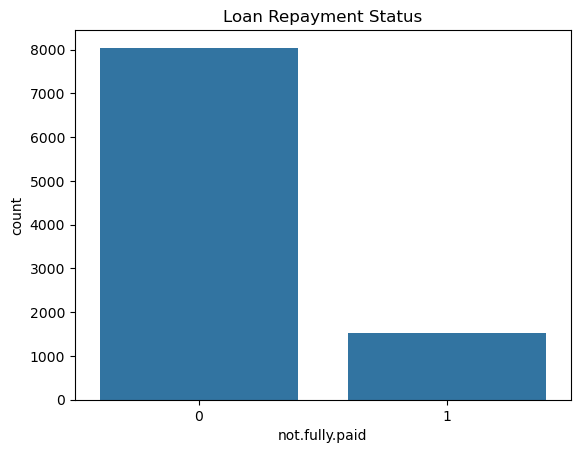

In [31]:
sns.countplot(x='not.fully.paid', data=loans)
plt.title('Loan Repayment Status')
plt.show()

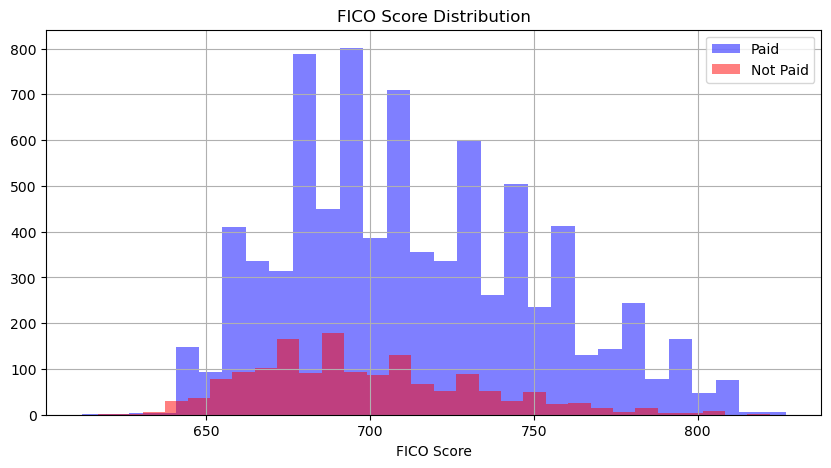

In [32]:
plt.figure(figsize=(10,5))
loans[loans['not.fully.paid']==0]['fico'].hist(alpha=0.5, color='blue', bins=30, label='Paid')
loans[loans['not.fully.paid']==1]['fico'].hist(alpha=0.5, color='red', bins=30, label='Not Paid')

plt.legend()
plt.xlabel('FICO Score')
plt.title('FICO Score Distribution')
plt.show()

### Most of the customers with lower Fico score have high probability of defaulting

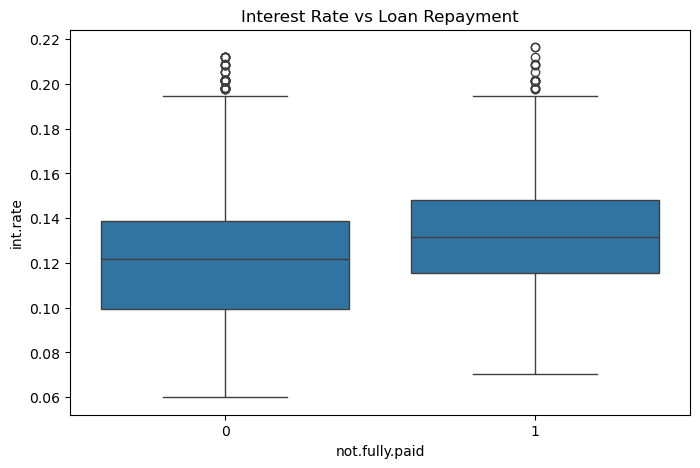

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x='not.fully.paid', y='int.rate', data=loans)
plt.title('Interest Rate vs Loan Repayment')
plt.show()

### Borrowers who fail to repay loans generally have higher interest rates.

## Data Preprocessing

In [34]:
loans= pd.get_dummies(loans, columns=['purpose'], drop_first=True)

In [35]:
X = loans.drop('not.fully.paid', axis=1)
y = loans['not.fully.paid']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=42)

In [37]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
svm_model = SVC(kernel='rbf')

svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [39]:
predictions = svm_model.predict(X_test)

## Model Evaluation

### Confusion matrix,classification report,accuracy score

In [40]:
print(confusion_matrix(y_test, predictions))

[[2407    1]
 [ 464    2]]


In [41]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91      2408
           1       0.67      0.00      0.01       466

    accuracy                           0.84      2874
   macro avg       0.75      0.50      0.46      2874
weighted avg       0.81      0.84      0.77      2874



In [42]:
accuracy = accuracy_score(y_test, predictions)
print('Accuracy:', accuracy)

Accuracy: 0.8382045929018789
